# E-Commerce Price Analysis
**Source:** Books to Scrape (books.toscrape.com)  
**Dataset:** 1000 books across 20 categories

In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
os.makedirs('images', exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

COLORS = sns.color_palette('Set2', 10)

df = pd.read_csv('data.csv')
# Restore ordered categorical for price_band so charts sort correctly
band_order = ['Budget (£0-10)', 'Mid (£10-20)', 'Upper-Mid (£20-35)', 'Premium (£35+)']
df['price_band'] = pd.Categorical(df['price_band'], categories=band_order, ordered=True)

print(f'Loaded {df.shape[0]} rows x {df.shape[1]} columns')
df

Loaded 1000 rows x 7 columns


,title,category,price_gbp,rating,availability,url,price_band
0,It's Only the Himalayas,Travel,45.17,2,In stock,https://books.toscrape.com/catalogue/its-only-...,Premium (£35+)
1,Full Moon over Noahâs Ark: An Odyssey to Mou...,Travel,49.43,4,In stock,https://books.toscrape.com/catalogue/full-moon...,Premium (£35+)
2,See America: A Celebration of Our National Par...,Travel,48.87,3,In stock,https://books.toscrape.com/catalogue/see-ameri...,Premium (£35+)
3,Vagabonding: An Uncommon Guide to the Art of L...,Travel,36.94,2,In stock,https://books.toscrape.com/catalogue/vagabondi...,Premium (£35+)
4,Under the Tuscan Sun,Travel,37.33,3,In stock,https://books.toscrape.com/catalogue/under-the...,Premium (£35+)
...,...,...,...,...,...,...,...
995,Why the Right Went Wrong: Conservatism--From G...,Politics,52.65,4,In stock,https://books.toscrape.com/catalogue/why-the-r...,Premium (£35+)
996,Equal Is Unfair: America's Misguided Fight Aga...,Politics,56.86,1,In stock,https://books.toscrape.com/catalogue/equal-is-...,Premium (£35+)
997,Amid the Chaos,Cultural,36.58,1,In stock,https://books.toscrape.com/catalogue/amid-the-...,Premium (£35+)
998,Dark Notes,Erotica,19.19,5,In stock,https://books.toscrape.com/catalogue/dark-note...,Mid (£10-20)


In [2]:
# Basic overview
print(df.dtypes)
print()
print(f'Categories   : {df["category"].nunique()}')
print(f'Price range  : £{df["price_gbp"].min():.2f} - £{df["price_gbp"].max():.2f}')
print(f'Average price: £{df["price_gbp"].mean():.2f}')
print(f'In stock     : {(df["availability"] == "In stock").sum()} ({(df["availability"] == "In stock").mean()*100:.1f}%)')
print()
print('Price band distribution:')
print(df['price_band'].value_counts().sort_index())

title                str
category             str
price_gbp        float64
rating             int64
availability         str
url                  str
price_band      category
dtype: object

Categories   : 50
Price range  : £10.00 - £59.99
Average price: £35.07
In stock     : 1000 (100.0%)

Price band distribution:
price_band
Budget (£0-10)          1
Mid (£10-20)          195
Upper-Mid (£20-35)    288
Premium (£35+)        516
Name: count, dtype: int64


## Price Distribution

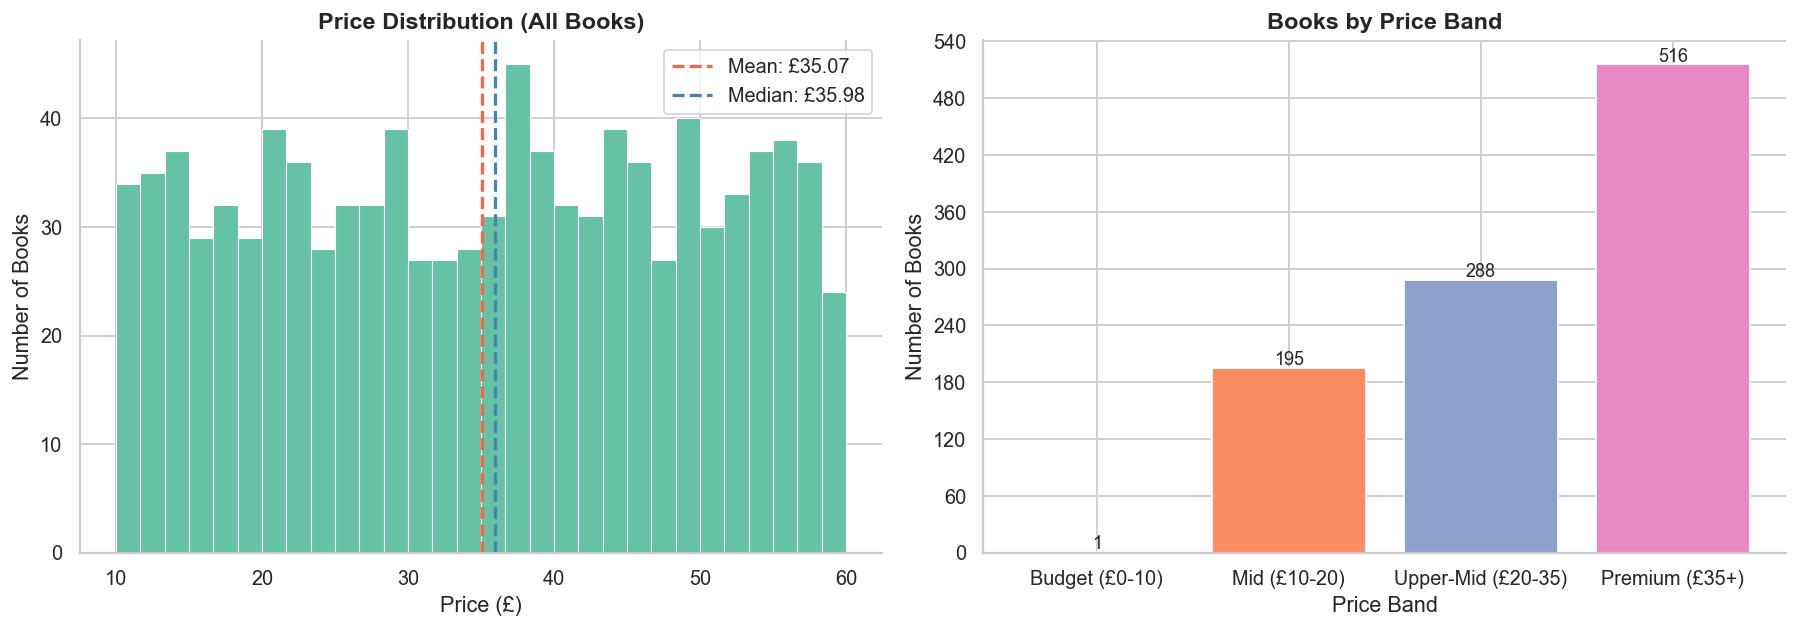

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of all prices
axes[0].hist(df['price_gbp'], bins=30, color=COLORS[0], edgecolor='white', linewidth=0.6)
axes[0].axvline(df['price_gbp'].mean(), color='tomato', linewidth=1.8, linestyle='--', label=f'Mean: £{df["price_gbp"].mean():.2f}')
axes[0].axvline(df['price_gbp'].median(), color='steelblue', linewidth=1.8, linestyle='--', label=f'Median: £{df["price_gbp"].median():.2f}')
axes[0].set_title('Price Distribution (All Books)')
axes[0].set_xlabel('Price (£)')
axes[0].set_ylabel('Number of Books')
axes[0].legend()

# Price band counts
band_counts = df['price_band'].value_counts().sort_index()
bars = axes[1].bar(band_counts.index, band_counts.values,
                   color=COLORS[:len(band_counts)], edgecolor='white')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
                 str(int(bar.get_height())), ha='center', fontsize=10)
axes[1].set_title('Books by Price Band')
axes[1].set_xlabel('Price Band')
axes[1].set_ylabel('Number of Books')
axes[1].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('images/chart_price_distribution.png', bbox_inches='tight')
plt.show()

## Average Price by Category

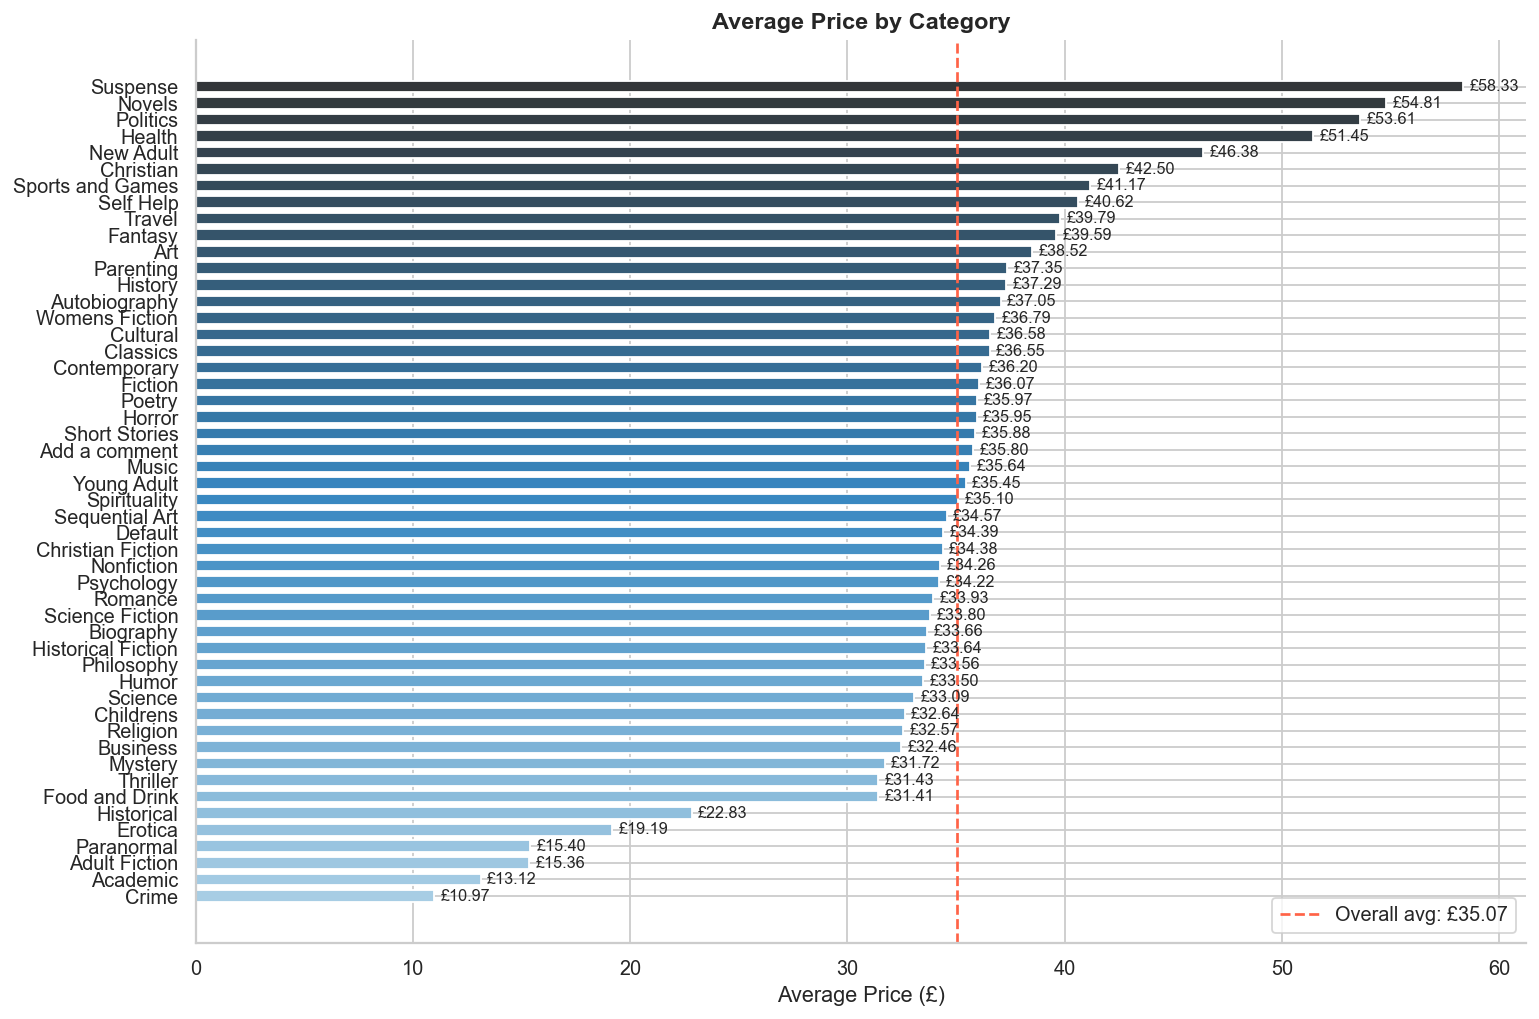

In [4]:
avg_by_cat = df.groupby('category')['price_gbp'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(avg_by_cat.index, avg_by_cat.values,
               color=sns.color_palette('Blues_d', len(avg_by_cat)), edgecolor='white', height=0.7)

for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'£{bar.get_width():.2f}', va='center', fontsize=9)

# Highlight overall average
ax.axvline(df['price_gbp'].mean(), color='tomato', linewidth=1.5,
           linestyle='--', label=f'Overall avg: £{df["price_gbp"].mean():.2f}')
ax.set_title('Average Price by Category')
ax.set_xlabel('Average Price (£)')
ax.set_ylabel('')
ax.legend()
plt.tight_layout()
plt.savefig('images/chart_avg_price_by_category.png', bbox_inches='tight')
plt.show()

## Price Range per Category (Box Plot)

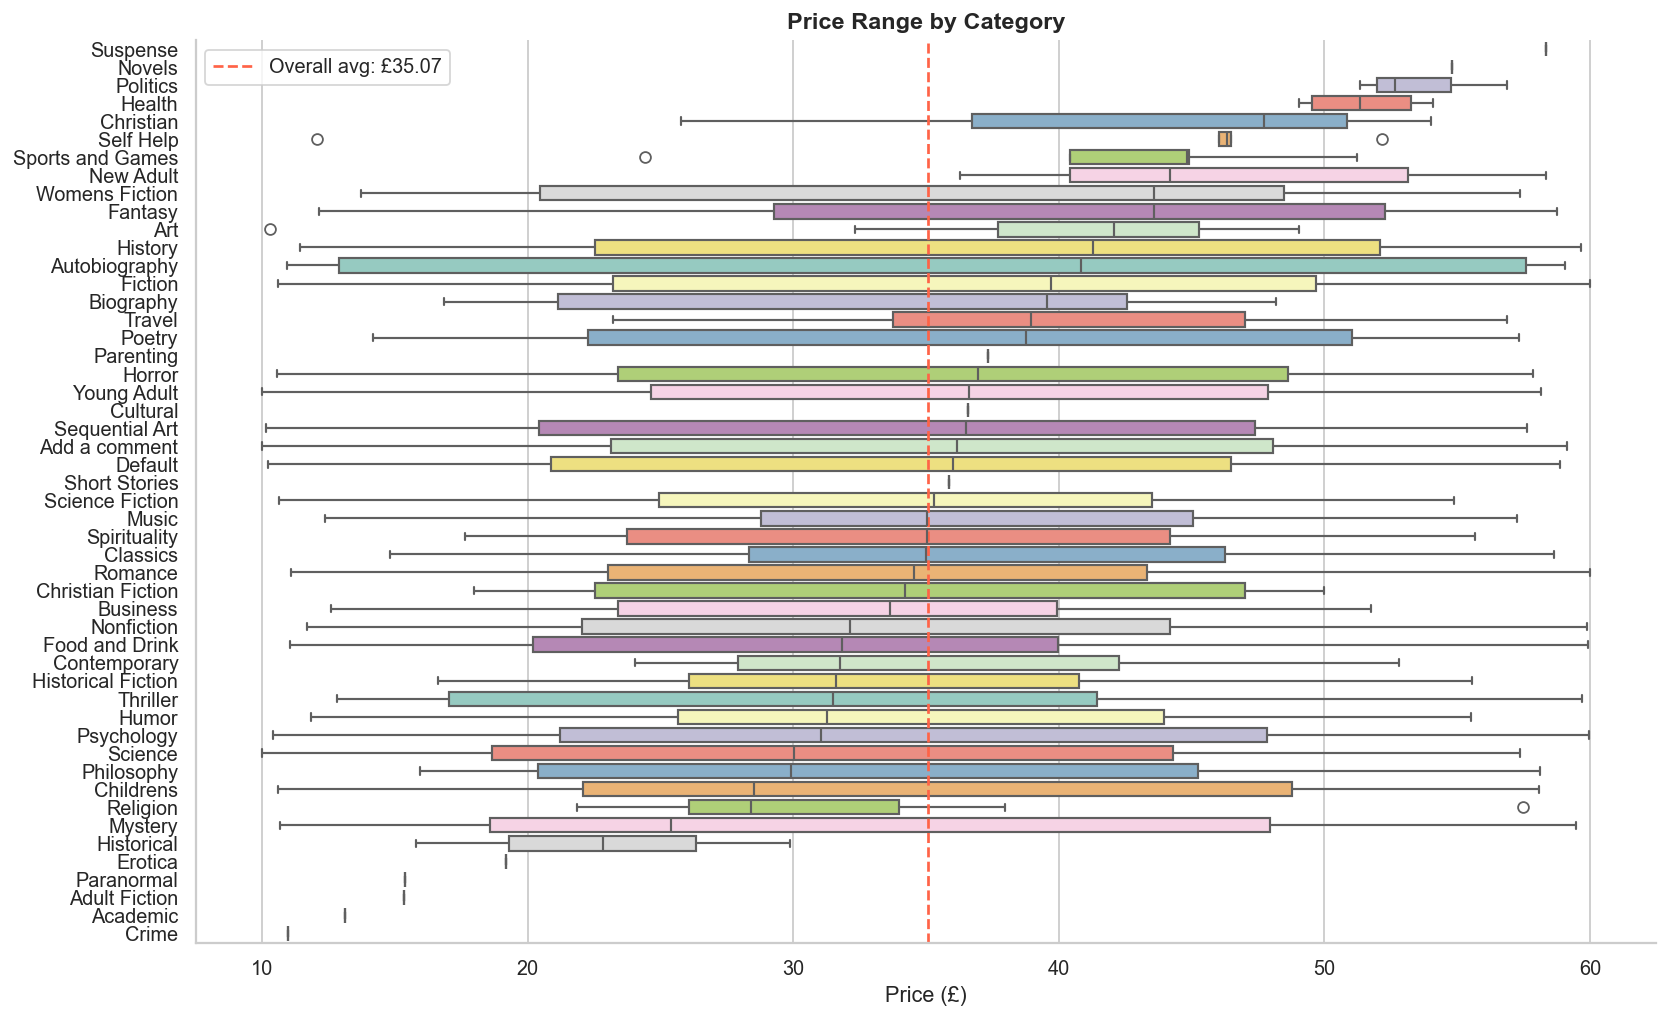

In [5]:
# Sort categories by median price for a clean visual
cat_order = df.groupby('category')['price_gbp'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(13, 8))
sns.boxplot(data=df, x='price_gbp', y='category', order=cat_order,
            palette='Set3', ax=ax, linewidth=1.2)
ax.axvline(df['price_gbp'].mean(), color='tomato', linewidth=1.5,
           linestyle='--', label=f'Overall avg: £{df["price_gbp"].mean():.2f}')
ax.set_title('Price Range by Category')
ax.set_xlabel('Price (£)')
ax.set_ylabel('')
ax.legend()
plt.tight_layout()
plt.savefig('images/chart_price_range_by_category.png', bbox_inches='tight')
plt.show()

## Number of Books per Category

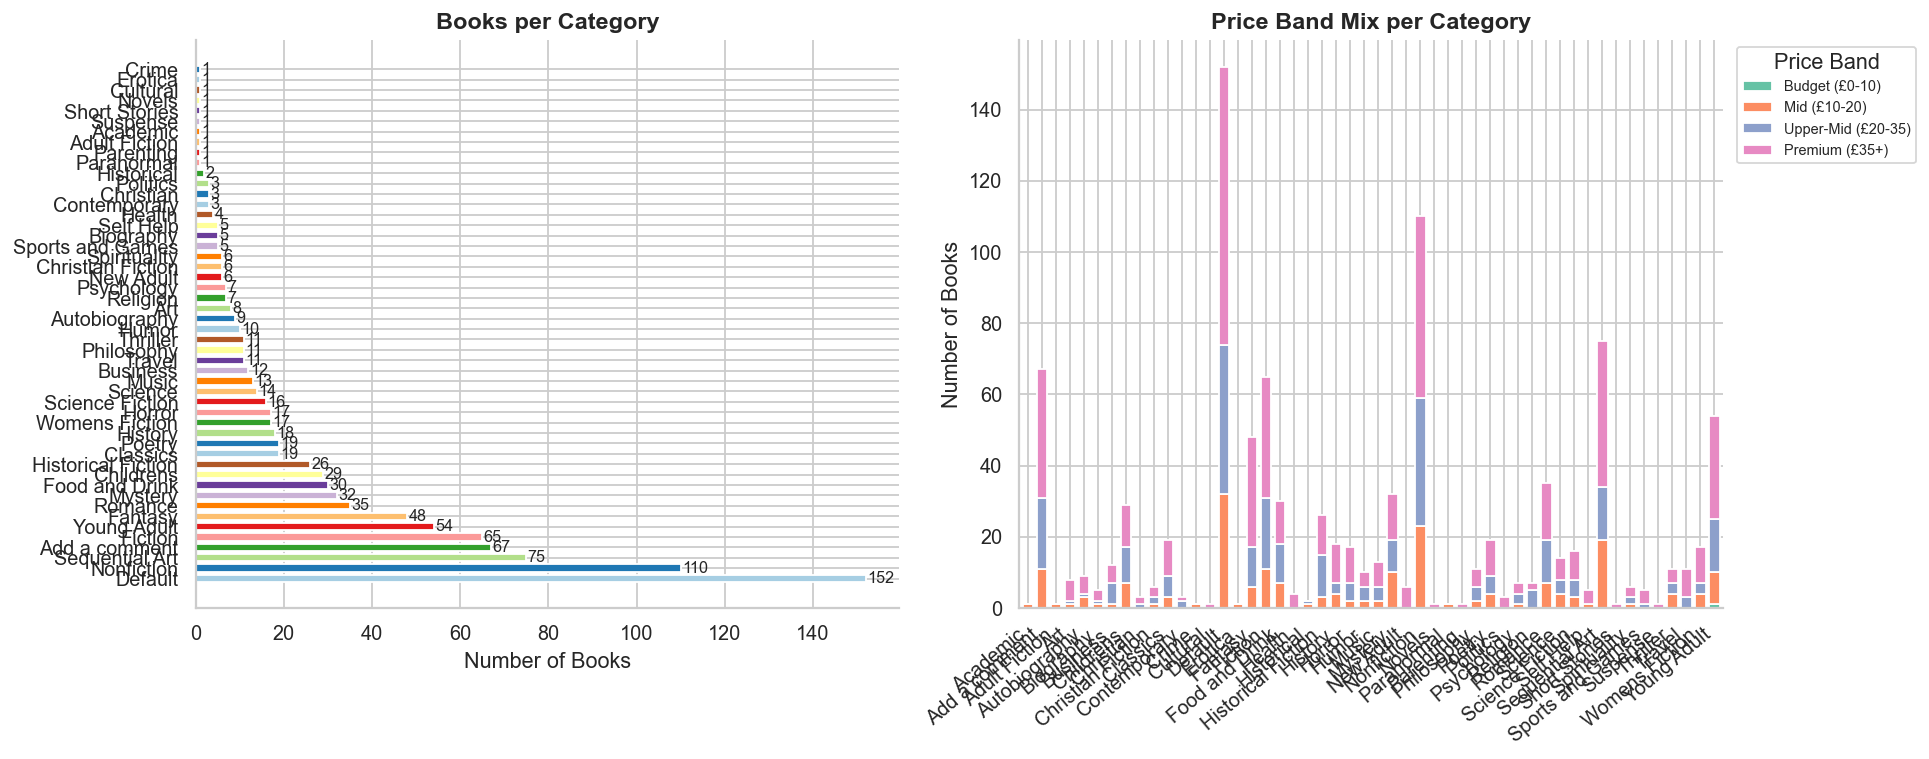

In [6]:
books_per_cat = df['category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart
bars = axes[0].barh(books_per_cat.index, books_per_cat.values,
                    color=sns.color_palette('Paired', len(books_per_cat)), edgecolor='white', height=0.7)
for bar in bars:
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 str(int(bar.get_width())), va='center', fontsize=9)
axes[0].set_title('Books per Category')
axes[0].set_xlabel('Number of Books')

# Price band breakdown per category (stacked bar)
cat_band = df.groupby(['category', 'price_band']).size().unstack(fill_value=0)[band_order]
cat_band.plot(kind='bar', stacked=True, ax=axes[1],
              color=COLORS[:4], edgecolor='white', width=0.75)
axes[1].set_title('Price Band Mix per Category')
axes[1].set_xlabel('')
axes[1].set_ylabel('Number of Books')
axes[1].legend(title='Price Band', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=40, ha='right')

plt.tight_layout()
plt.savefig('images/chart_books_per_category.png', bbox_inches='tight')
plt.show()

## Rating vs Price

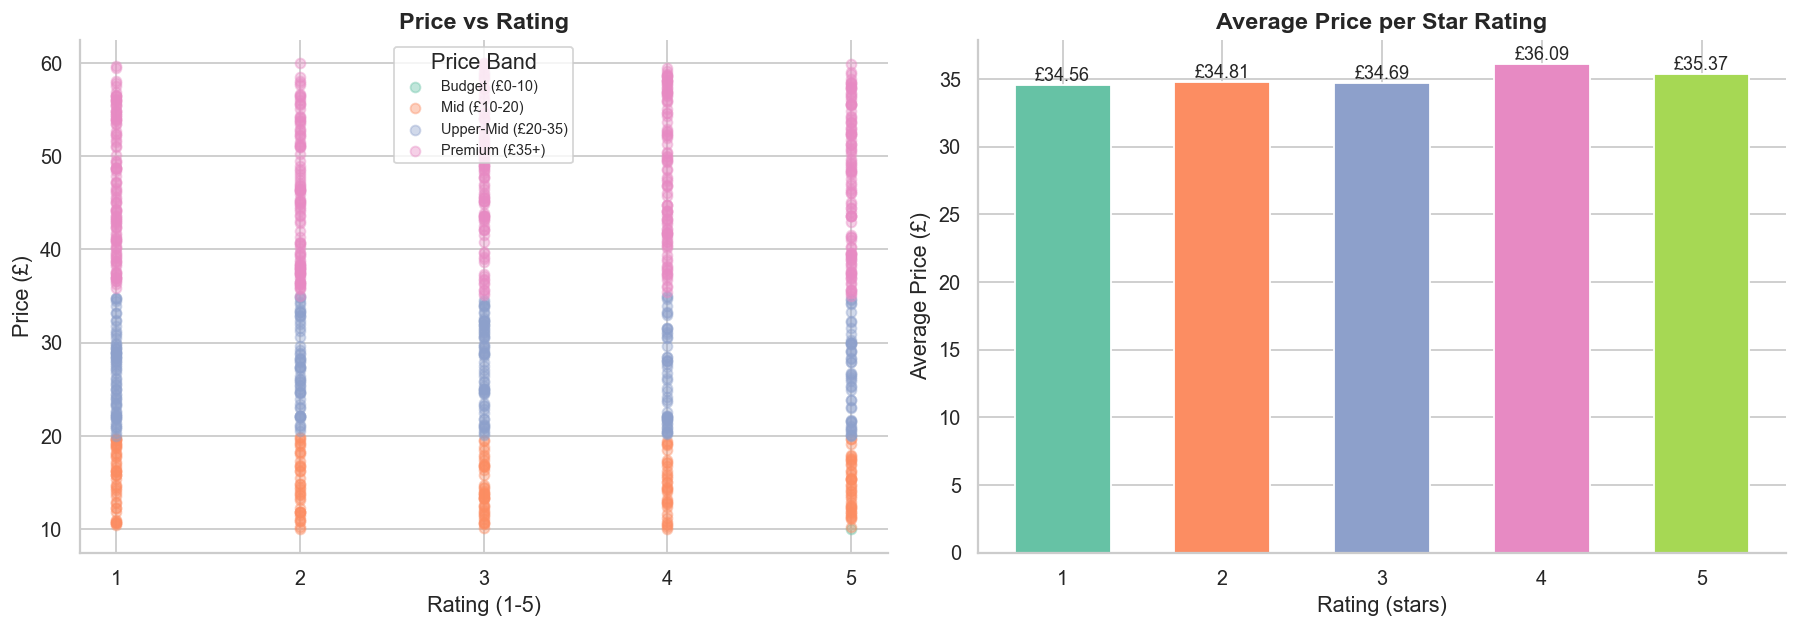

Correlation between price and rating: 0.028


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot — price vs rating
for i, band in enumerate(band_order):
    subset = df[df['price_band'] == band]
    axes[0].scatter(subset['rating'], subset['price_gbp'],
                    alpha=0.4, s=30, color=COLORS[i], label=band)
axes[0].set_title('Price vs Rating')
axes[0].set_xlabel('Rating (1-5)')
axes[0].set_ylabel('Price (£)')
axes[0].legend(title='Price Band', fontsize=8)
axes[0].set_xticks([1, 2, 3, 4, 5])

# Average price per star rating
avg_price_rating = df.groupby('rating')['price_gbp'].mean()
bars = axes[1].bar(avg_price_rating.index, avg_price_rating.values,
                   color=COLORS[:5], edgecolor='white', width=0.6)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f'£{bar.get_height():.2f}', ha='center', fontsize=10)
axes[1].set_title('Average Price per Star Rating')
axes[1].set_xlabel('Rating (stars)')
axes[1].set_ylabel('Average Price (£)')
axes[1].set_xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.savefig('images/chart_rating_vs_price.png', bbox_inches='tight')
plt.show()

# Correlation
corr = df['price_gbp'].corr(df['rating'])
print(f'Correlation between price and rating: {corr:.3f}')

## Availability Analysis

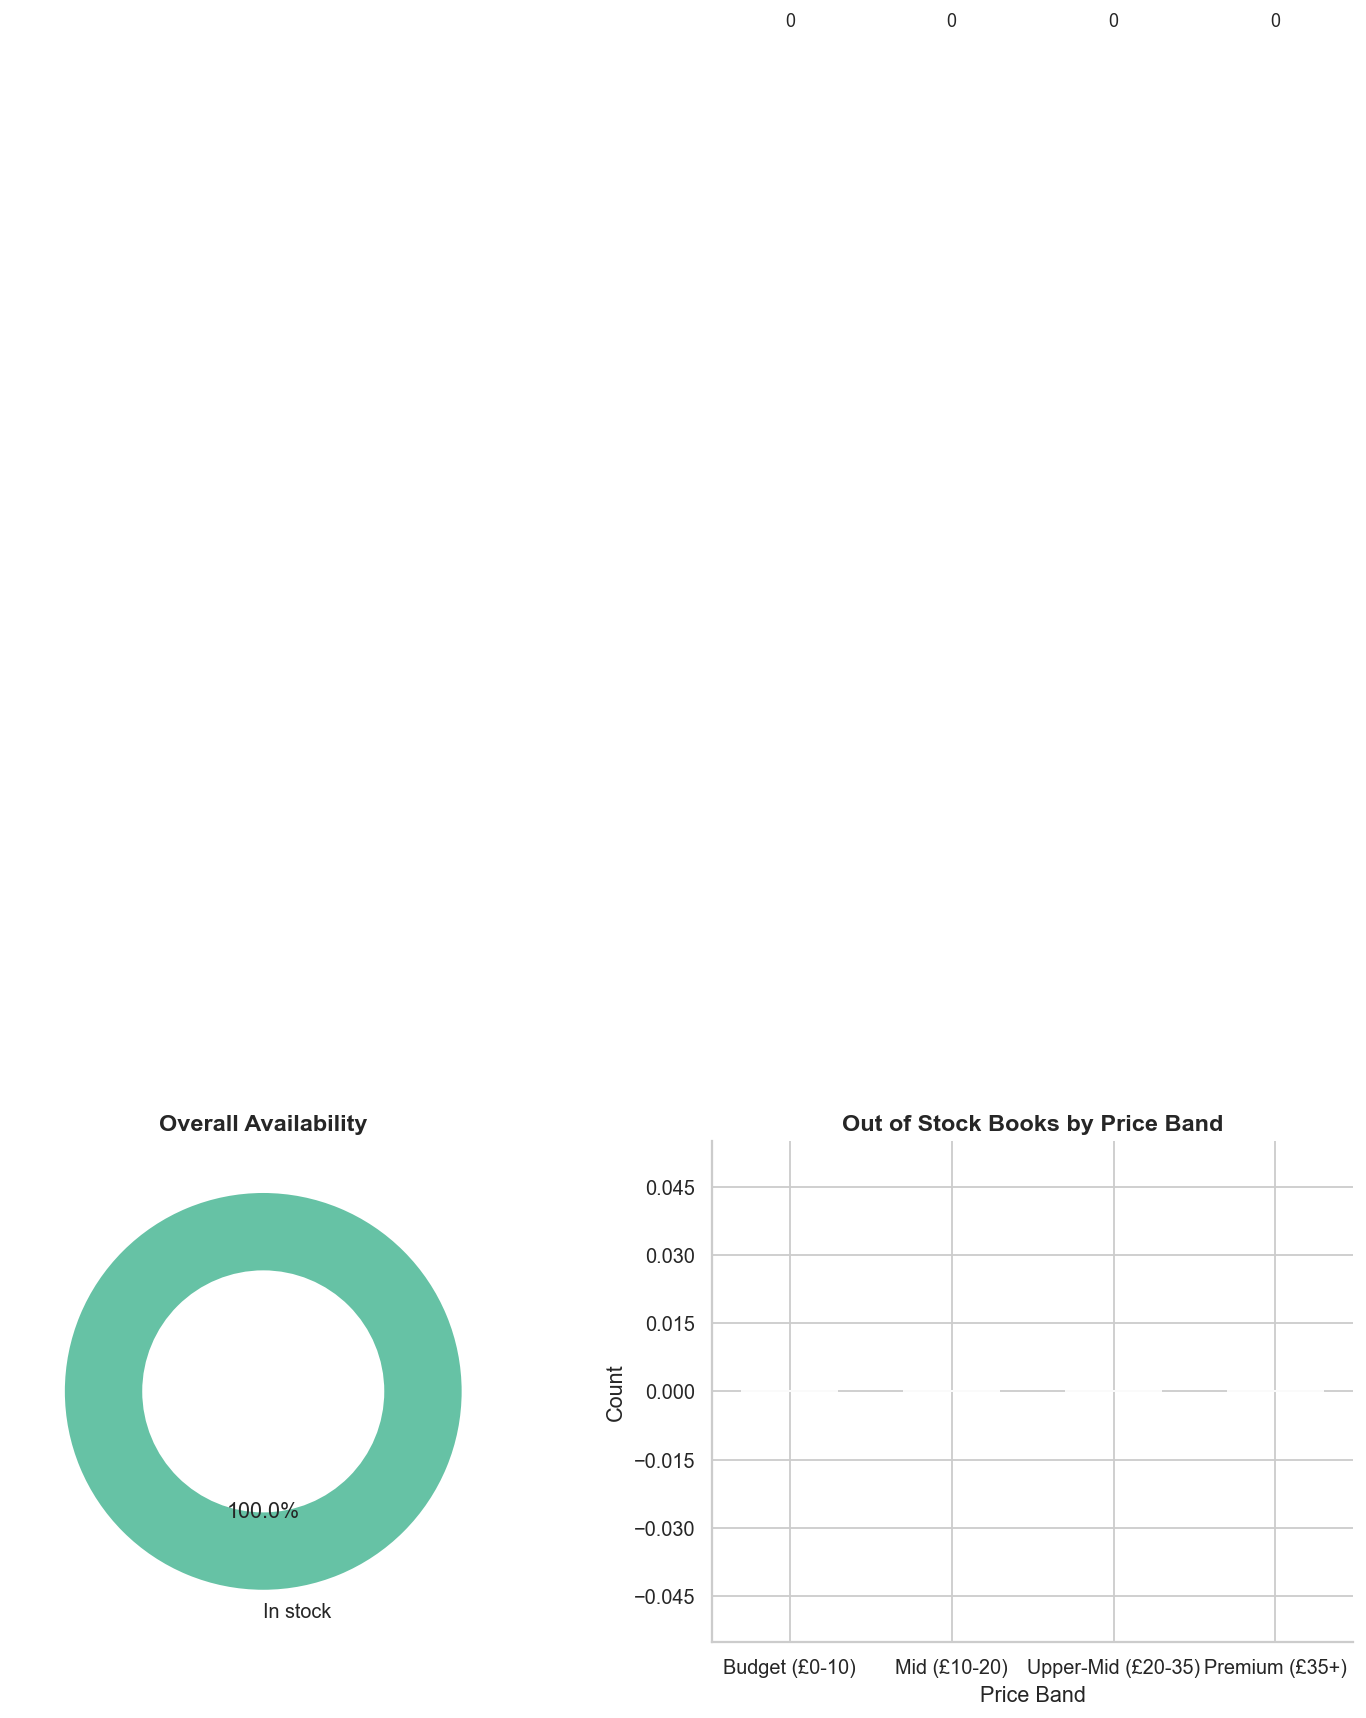

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall availability donut
avail_counts = df['availability'].value_counts()
wedges, texts, autotexts = axes[0].pie(
    avail_counts.values, labels=avail_counts.index,
    autopct='%1.1f%%', colors=[COLORS[0], COLORS[2]],
    startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].add_patch(plt.Circle((0, 0), 0.6, fc='white'))
axes[0].set_title('Overall Availability')

# Out of stock by price band
oos = df[df['availability'] == 'Out of stock']['price_band'].value_counts().sort_index()
axes[1].bar(oos.index, oos.values, color=COLORS[3], edgecolor='white', width=0.6)
for i, v in enumerate(oos.values):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontsize=10)
axes[1].set_title('Out of Stock Books by Price Band')
axes[1].set_xlabel('Price Band')
axes[1].set_ylabel('Count')
axes[1].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('images/chart_availability.png', bbox_inches='tight')
plt.show()

## Price Heatmap — Category vs Price Band

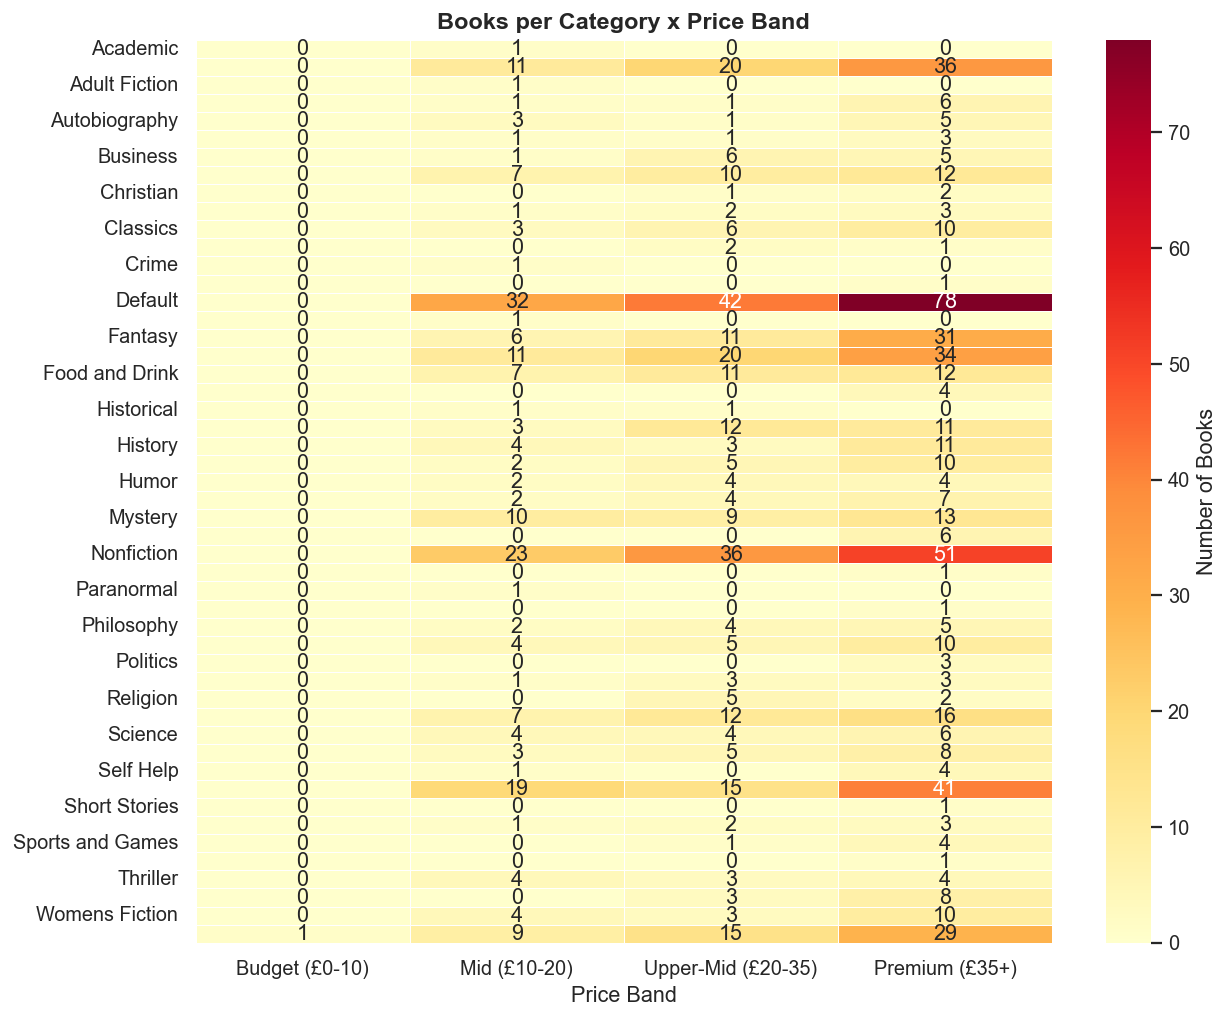

In [9]:
heatmap_data = df.groupby(['category', 'price_band']).size().unstack(fill_value=0)[band_order]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Number of Books'})
ax.set_title('Books per Category x Price Band')
ax.set_xlabel('Price Band')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('images/chart_category_price_heatmap.png', bbox_inches='tight')
plt.show()

## Summary

In [10]:
most_expensive_cat = df.groupby('category')['price_gbp'].mean().idxmax()
cheapest_cat       = df.groupby('category')['price_gbp'].mean().idxmin()
top_rated_cat      = df.groupby('category')['rating'].mean().idxmax()
most_books_cat     = df['category'].value_counts().idxmax()
corr               = df['price_gbp'].corr(df['rating'])
in_stock_pct       = (df['availability'] == 'In stock').mean() * 100

print(f'Total books          : {len(df)}')
print(f'Total categories     : {df["category"].nunique()}')
print(f'Average price        : £{df["price_gbp"].mean():.2f}')
print(f'Most expensive cat   : {most_expensive_cat} (avg £{df.groupby("category")["price_gbp"].mean()[most_expensive_cat]:.2f})')
print(f'Cheapest category    : {cheapest_cat} (avg £{df.groupby("category")["price_gbp"].mean()[cheapest_cat]:.2f})')
print(f'Highest rated cat    : {top_rated_cat}')
print(f'Most books in        : {most_books_cat} ({df["category"].value_counts()[most_books_cat]} books)')
print(f'In stock             : {in_stock_pct:.1f}%')
print(f'Price-rating corr    : {corr:.3f} (weak — price does not predict rating)')

Total books          : 1000
Total categories     : 50
Average price        : £35.07
Most expensive cat   : Suspense (avg £58.33)
Cheapest category    : Crime (avg £10.97)
Highest rated cat    : Adult Fiction
Most books in        : Default (152 books)
In stock             : 100.0%
Price-rating corr    : 0.028 (weak — price does not predict rating)
